## Setup Libraries

In [1]:
# !pip install -q uv

In [2]:
try:
    import xgboost
except:
    !pip install -q xgboost
    import xgboost

try:
    import lightgbm
except:
    !pip install -q lightgbm
    import lightgbm

try:
    import catboost
except:
    !pip install -q catboost
    import catboost

try:
    from colorama import Fore, Style
except:
    !pip install -q colorama
    from colorama import Fore, Style


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# !uv pip install -q pytabkit
try:
    from pytabkit import (
            # RealMLP_TD_Classifier,
            # TabM_D_Classifier,
            # Resnet_RTDL_D_Classifier,
            # MLP_RTDL_D_Classifier,
            # MLP_PLR_D_Classifier,
            # TabR_S_D_Classifier,
            # FTT_D_Classifier,
            XGB_TD_Classifier,
            LGBM_TD_Classifier,
            CatBoost_TD_Classifier,
)
except:
    !pip install -q pytabkit
    from pytabkit import (
            # RealMLP_TD_Classifier,
            # TabM_D_Classifier,
            # Resnet_RTDL_D_Classifier,
            # MLP_RTDL_D_Classifier,
            # MLP_PLR_D_Classifier,
            # TabR_S_D_Classifier,
            # FTT_D_Classifier,
            XGB_TD_Classifier,
            LGBM_TD_Classifier,
            CatBoost_TD_Classifier,
)


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


In [4]:
import os, sys
import torch
import numpy as np, random
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import gc

from importlib.metadata import version

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import QuantileTransformer, OrdinalEncoder, LabelEncoder, KBinsDiscretizer, TargetEncoder

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 500)

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
seed_everything(42)

print("PyTorch  version:", torch.__version__)
print("PyTabKit version:", version("pytabkit"))

PyTorch  version: 2.8.0+cpu
PyTabKit version: 1.7.3


## Load Data

In [5]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
orig = pd.read_csv("/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv")
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Orig shape :", orig.shape)

train

Train shape: (668665, 15)
Test shape : (286571, 14)
Orig shape : (10000, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


## Preprocess Features

In [6]:
%%time

ID = 'id'
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET] = orig[TARGET].map({'No': 0, 'Yes': 1})
X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
y = train[TARGET]
X_test = test.drop([ID], axis=1); test_id = test[ID]
del train, test
print("X      init shape:", X.shape)
print("X_test init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('Annual_Income_USD', 'Range_Anxiety_Level'),
    ('Age', 'Range_Anxiety_Level'),
    ('Annual_Income_USD', 'Income_/_100_floor_'),
]
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)

    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype('category')

    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1e-6)).astype('float32')
    df['Income_/_100_floor_'] = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype('category')
    df['Income_/_1000_floor_'] = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype('category')
    df['Income_/_10000_floor_'] = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype('category')
    df['Daily_km_/_5_floor_'] = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype('category')

    # Categorize numericals
    for col in [i for i in num_cols if i not in ['Annual_Income_USD', 'Charging_Stations_Near_Home']]:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = np.floor(df[col]).factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype('category')

    # Digit extraction
    for col in ['Daily_Commute_km']:
        decimal_name = f"_{col}_decimal"
        df[decimal_name] = (df[col] % 1).round(2).astype('float32')
    df['Annual_Income_USD_is_multiple_10_'] = (np.floor(df['Annual_Income_USD']) % 10 == 0).astype('category')

    # Target encoding from orig
    for col in ['Annual_Income_USD']:
        orig_enc_name = f"_{col}_mean_target_orig"
        df[orig_enc_name] = (
            df[col]
            .map(orig.groupby(col)[TARGET].mean())
            .fillna(orig[TARGET].mean())
            .astype('float32')
        )

    # Count encoding
    for col in ['Annual_Income_USD']:
        count_name = f"_{col}_count"
        if fit:
            count_map = df[col].value_counts()
            category_map[count_name] = count_map
        else:
            count_map = category_map[count_name]
        df[count_name] = df[col].astype(object).map(count_map).fillna(0).astype('int32')

    # Discretize numericals
    bin_config = {'Annual_Income_USD': [400, 600, 800, 900, 1100]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype('category')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category')   

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, _, _, _ = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X

X      init shape: (668665, 13)
X_test init shape: (286571, 13) 

init len(cat_cols): 6
init len(num_cols): 7 



len(new_cat_cols): 18
len(new_num_cols): 4 

prep len(cat_cols): 24
prep len(num_cols): 11 

X      prep shape: (668665, 35)
X_test prep shape: (286571, 35) 

CPU times: user 3 s, sys: 187 ms, total: 3.18 s
Wall time: 3.22 s


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,False,0.000000,96,214,321,427,482,584,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,True,0.066427,61605,0,0,0,0,0,1,1,1
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,False,1.000000,45,225,336,448,505,612,2,2,2
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,True,1.000000,177,96,144,191,216,262,3,0,3
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,False,0.500000,290,27,40,53,60,73,4,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,True,1.000000,81,80,119,159,180,218,9486,47,6094
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,True,0.000000,82,338,506,675,760,925,161,19,160
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,False,0.000000,175,321,480,640,721,876,3076,45,2836
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,False,0.175000,2,307,459,612,689,838,14312,16,9197


In [7]:
X.nunique()

Age                                          45
Annual_Income_USD                         13214
Daily_Commute_km                            805
Number_of_Cars_Owned                          4
Charging_Stations_Near_Home                  15
Charging_Stations_Near_Work                  20
Environmental_Concern_Level                   5
Gender                                        3
City_Type                                     3
Current_Car_Type                              4
Home_Charging_Possible                        2
Subsidy_Available                             2
Range_Anxiety_Level                           3
_Daily_Commute_km_/_Age                   22554
Income_/_100_floor_                        1142
Income_/_1000_floor_                        150
Income_/_10000_floor_                        16
Daily_km_/_5_floor_                          19
Age_cat_                                     45
Daily_Commute_km_cat_                        89
Number_of_Cars_Owned_cat_               

## Config

In [8]:
xgb_m = XGB_TD_Classifier(**{
    'n_estimators': 10_000, # d=1000
    'max_depth': 4, # d=6
    'lr': 0.03, # d=0.08
    'subsample': 0.9, # d=0.65
    'colsample_bytree': 0.8, # d=0.9
    # # 'colsample_bylevel': 0.75, # d=0.9
    # 'alpha': 3.0,
    # 'reg_lambda': 0.1, # d=0.0
    'min_child_weight': 40, # d=5e-06
    # # 'max_bin': 1015, # d=256
    # # 'max_cat_to_onehot': 10,
    # # 'verbosity': 0,
    # # 'n_threads': os.cpu_count(),
    'val_metric_name': "1-auc_ovr",
    'random_state': 42,
})

lgb_m = LGBM_TD_Classifier(**{
    'n_estimators': 10_000, # d=1000
    'num_leaves': 31, # d=50
    'lr': 0.03, # d=0.04
    # -------------------------------
    # # 'max_bin': 600, # d=255
    'min_data_in_leaf': 30, # d=40
    # -------------------------------
    'subsample': 0.9, # d=0.75
    'colsample_bytree': 0.85, # d=1.0
    # 'bagging_freq': 2, # d=1
    # -------------------------------
    # 'lambda_l1': 0.01,
    'lambda_l2': 0.1,
    'val_metric_name': "1-auc_ovr",
    'random_state': 42,
})

cat_bay = CatBoost_TD_Classifier(**{
    'bootstrap_type': "Bayesian",
    # -------------------------------
    'n_estimators': 10_000, # d=1000
    # 'max_depth': 6, # d=7
    # 'lr': 0.04, # d=0.08
    # 'max_bin': 512, # d=254
    # -------------------------------
    'l2_leaf_reg': 1.0, # d=1e-05
    # # 'leaf_estimation_iterations': 5, d=1
    # 'random_strength': 0.6, # d=0.8
    # -------------------------------
    # 'one_hot_max_size': 10, # d=15
    # 'verbosity': 0,
    'random_state': 42,
})

cat_ben = CatBoost_TD_Classifier(**{
    'bootstrap_type': "Bernoulli",
    'n_estimators': 10_000,
    # 'subsample': 0.8, # d=0.9
    # 'max_depth': 6,
    'lr': 0.03,
    # 'l2_leaf_reg': 0.1,
    # 'random_strength': 0.6,
    # 'one_hot_max_size': 10,
    # 'max_bin': 254,
    # 'verbosity': 0,
    'random_state': 42,
})

all_models = {
    # ('Pyrealmlp65', realmlp),     # GPU
    # ('Pytabm65', tabm),           # GPU
    # ('Pymlp_plr65', mlp_plr),     # GPU
    # ('Pymlp_rtd65', mlp_rtd),     # GPU
    # ('Pyresnet65', resnet_rtd),   # GPU
    'xgb': ('pytab_XGB(38)', xgb_m),       # GPU | TPU
    'lgb': ('pytab_LGBM(38)', lgb_m),      # CPU
    'cat0': ('pytab_CATbay(38)', cat_bay), # TPU
    'cat1': ('pytab_CATben(38)', cat_ben), # TPU
}

print("🤖 Model parameters defined!")

all_models

🤖 Model parameters defined!


{'xgb': ('pytab_XGB(38)',
  XGB_TD_Classifier(colsample_bytree=0.8, lr=0.03, max_depth=4,
                    min_child_weight=40, n_estimators=10000, random_state=42,
                    subsample=0.9, val_metric_name='1-auc_ovr')),
 'lgb': ('pytab_LGBM(38)',
  LGBM_TD_Classifier(colsample_bytree=0.85, lambda_l2=0.1, lr=0.03,
                     min_data_in_leaf=30, n_estimators=10000, num_leaves=31,
                     random_state=42, subsample=0.9, val_metric_name='1-auc_ovr')),
 'cat0': ('pytab_CATbay(38)',
  CatBoost_TD_Classifier(bootstrap_type='Bayesian', l2_leaf_reg=1.0,
                         n_estimators=10000, random_state=42)),
 'cat1': ('pytab_CATben(38)',
  CatBoost_TD_Classifier(bootstrap_type='Bernoulli', lr=0.03, n_estimators=10000,
                         random_state=42))}

In [9]:
USE_FULL_TRAIN = True

x_sample, x_sample2 = train_test_split(pd.concat([X, y], axis=1), train_size=300_000, stratify=y, random_state=0)
train_X = pd.concat([X, y], axis=1).copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

print(train_X.shape)
train_X

(668665, 36)


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,False,0.000000,96,214,321,427,482,584,0,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,True,0.066427,61605,0,0,0,0,0,1,1,1,0
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,False,1.000000,45,225,336,448,505,612,2,2,2,1
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,True,1.000000,177,96,144,191,216,262,3,0,3,0
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,False,0.500000,290,27,40,53,60,73,4,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,True,1.000000,81,80,119,159,180,218,9486,47,6094,0
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,True,0.000000,82,338,506,675,760,925,161,19,160,0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,False,0.000000,175,321,480,640,721,876,3076,45,2836,0
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,False,0.175000,2,307,459,612,689,838,14312,16,9197,0


## Train K-Fold

In [10]:
%%time

_model = 'cat0'
MODEL_NAME = all_models[_model][0]

USE_TE = True
FOLDS  = 10

X_1 = train_X.drop([TARGET], axis=1)
y_1 = train_X[TARGET]

print(f"\n🚀 Training {MODEL_NAME} with {FOLDS } folds...")
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_1))
test_preds = np.zeros(len(X_test))

fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_1, y_1), 1):
    X_tr, X_val = X_1.iloc[tr_idx].copy(), X_1.iloc[val_idx].copy()
    y_tr, y_val = y_1.iloc[tr_idx], y_1.iloc[val_idx]
    X_tst = X_test.copy()  

    # Target encoding
    if USE_TE:
        te_cols = combo_names
        print(f"Target encoding ({len(te_cols)}) features")
        TE = TargetEncoder(cv=5, smooth='auto', shuffle=True, random_state=42)
        tr_enc = TE.fit_transform(X_tr[te_cols], y_tr)
        val_enc = TE.transform(X_val[te_cols])
        tst_enc = TE.transform(X_tst[te_cols])

        te_names = [f"_{col}TE" for col in te_cols]
        X_tr[te_names]  = tr_enc
        X_val[te_names] = val_enc
        X_tst[te_names] = tst_enc

    # if fold == 1: print("len(FEATURES):", len(X_tr.columns.tolist()), "\n")
    print("-"*55)
    print(f"### Fold {fold}/{FOLDS}", end=" | "); print(f"train={X_tr.shape}, valid={X_val.shape}")
    print("-"*55)

    model = all_models[_model][1]
    model.fit(X_tr, y_tr, X_val, y_val) # , cat_col_names=cat_cols

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_tst)[:, 1] / FOLDS

    fold_score = roc_auc_score(y_val, oof_preds[val_idx])
    fold_scores.append(fold_score)
    print(f"{Fore.YELLOW}{Style.BRIGHT} -> Fold {fold} | AUC: {fold_score:.6f}{Style.RESET_ALL}\n")

    torch.cuda.empty_cache()

oof_auc = np.round(roc_auc_score(y_1, oof_preds), 6)

## - CV summary -  
print("\n==================================================")  
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | {X_tr.shape}")
print("==================================================")  
for i, score in enumerate(fold_scores, 1):  
    print(f" • Fold {i} AUC: {score:.6f}")  

print('-'*50)
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-"*50)


🚀 Training pytab_CATbay(38) with 10 folds...
Target encoding (3) features


-------------------------------------------------------
### Fold 1/10 | train=(601798, 38), valid=(66867, 38)
-------------------------------------------------------


 -> Fold 1 | AUC: 0.944424

Target encoding (3) features


-------------------------------------------------------
### Fold 2/10 | train=(601798, 38), valid=(66867, 38)
-------------------------------------------------------


 -> Fold 2 | AUC: 0.944672

Target encoding (3) features


...

 -> Fold 8 | AUC: 0.946282

Target encoding (3) features


-------------------------------------------------------
### Fold 9/10 | train=(601799, 38), valid=(66866, 38)
-------------------------------------------------------


 -> Fold 9 | AUC: 0.946406

Target encoding (3) features


-------------------------------------------------------
### Fold 10/10 | train=(601799, 38), valid=(66866, 38)
-------------------------------------------------------


 -> Fold 10 | AUC: 0.944619


10-FOLD CV: pytab_CATbay(38) | (601799, 38)
 • Fold 1 AUC: 0.944424
 • Fold 2 AUC: 0.944672
 • Fold 3 AUC: 0.944725
 • Fold 4 AUC: 0.945546
 • Fold 5 AUC: 0.946428
 • Fold 6 AUC: 0.946583
 • Fold 7 AUC: 0.945639
 • Fold 8 AUC: 0.946282
 • Fold 9 AUC: 0.946406
 • Fold 10 AUC: 0.944619
--------------------------------------------------
OOF AUC: 0.945523
AVG AUC: 0.945533 ± 0.000818
--------------------------------------------------
CPU times: user 1d 2h 46min 14s, sys: 5h 18min 4s, total: 1d 8h 4min 18s
Wall time: 25min 1s


In [11]:
# print(sys.getsizeof(model)/(1024**2), 'mb')

In [12]:
## - CV summary -  
print("\n==================================================")  
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | {X_tr.shape}")
print("==================================================")  
for i, score in enumerate(fold_scores, 1):  
    print(f" • Fold {i} AUC: {score:.6f}")  

print('-'*50)
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-"*50)


10-FOLD CV: pytab_CATbay(38) | (601799, 38)
 • Fold 1 AUC: 0.944424
 • Fold 2 AUC: 0.944672
 • Fold 3 AUC: 0.944725
 • Fold 4 AUC: 0.945546
 • Fold 5 AUC: 0.946428
 • Fold 6 AUC: 0.946583
 • Fold 7 AUC: 0.945639
 • Fold 8 AUC: 0.946282
 • Fold 9 AUC: 0.946406
 • Fold 10 AUC: 0.944619
--------------------------------------------------
OOF AUC: 0.945523
AVG AUC: 0.945533 ± 0.000818
--------------------------------------------------


In [13]:
# ===================================
# pytab_CATben38 OOF AUC: 0.943938
# ===================================
# Wall time: 13min 13s

# ===================================
# pytab_CATbay38 OOF AUC: 0.943891
# ===================================
# Wall time: 15min 55s

# ===================================
# pytab_XGB38 OOF AUC: 0.943637
# ===================================
# Wall time: 4min 5s

# ===================================
# pytab_LGBM38 OOF AUC: 0.941176
# ===================================
# Wall time: 2min 7s

## Evaluation and Submission

In [14]:
# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{MODEL_NAME}_{oof_auc}.npy", oof_preds)
print(f"💾 Saved 'oof_{MODEL_NAME}_{oof_auc}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{MODEL_NAME}_{oof_auc}.npy", test_preds)
print(f"💾 Saved 'test_{MODEL_NAME}_{oof_auc}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{MODEL_NAME}_{oof_auc}.csv", index=False)
print(f"💾 Saved 'submission_{MODEL_NAME}_{oof_auc}.csv'")

print()
submission

💾 Saved 'oof_pytab_CATbay(38)_0.945523.npy'
💾 Saved 'test_pytab_CATbay(38)_0.945523.npy'


💾 Saved 'submission_pytab_CATbay(38)_0.945523.csv'



,id,Will_Buy_EV
0,668665,0.024194
1,668666,0.016461
2,668667,0.003675
3,668668,0.003051
4,668669,0.041296
...,...,...
286566,955231,0.000454
286567,955232,0.278899
286568,955233,0.001650
286569,955234,0.000653


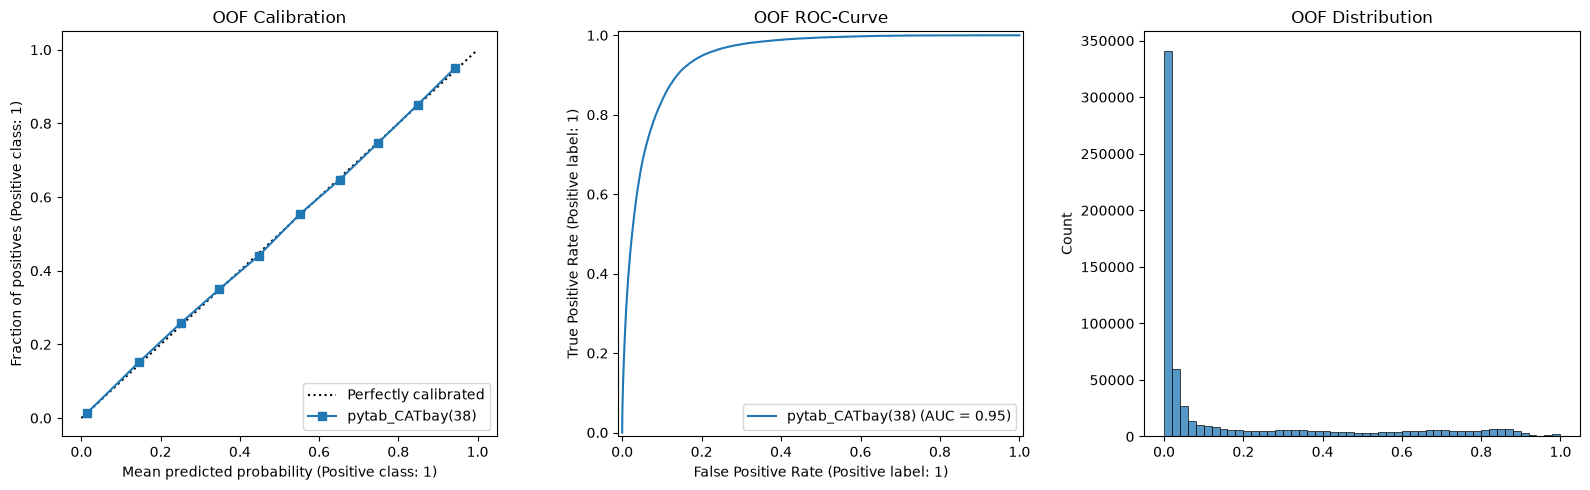

In [15]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5))

CalibrationDisplay.from_predictions(y_1, oof_preds, n_bins=10, name=MODEL_NAME, ax=axs[0])
axs[0].set_title(f"OOF Calibration")

RocCurveDisplay.from_predictions(y_1, oof_preds, name=MODEL_NAME, ax=axs[1])
axs[1].set_title(f"OOF ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"OOF Distribution")

plt.tight_layout()
plt.show()

In [16]:
# !rm -r /kaggle/working/